In [1]:
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)
n = 1000

data = {
    'age': np.random.randint(18, 70, n),
    'tenure_months': np.random.randint(1, 72, n),
    'monthly_charges': np.random.uniform(20, 100, n).round(2),
    'num_products': np.random.randint(1, 5, n),
    'has_internet': np.random.randint(0, 2, n),
    'has_phone': np.random.randint(0, 2, n),
    'customer_service_calls': np.random.randint(0, 10, n),
}

df = pd.DataFrame(data)

# Create target variable (1 = churned, 0 = stayed)
df['churn'] = (
    (df['customer_service_calls'] > 4) |
    (df['tenure_months'] < 12) |
    (df['monthly_charges'] > 80)
).astype(int)

print("Dataset created successfully!")
print("Shape:", df.shape)
print("\nChurn Distribution:")
print(df['churn'].value_counts())
df.head()

Dataset created successfully!
Shape: (1000, 8)

Churn Distribution:
churn
1    714
0    286
Name: count, dtype: int64


,age,tenure_months,monthly_charges,num_products,has_internet,has_phone,customer_service_calls,churn
0,56,15,48.13,2,0,1,8,1
1,69,64,28.11,1,1,1,3,0
2,46,28,58.87,4,0,1,8,1
3,32,39,40.54,4,0,1,3,0
4,60,57,42.79,2,1,1,1,0


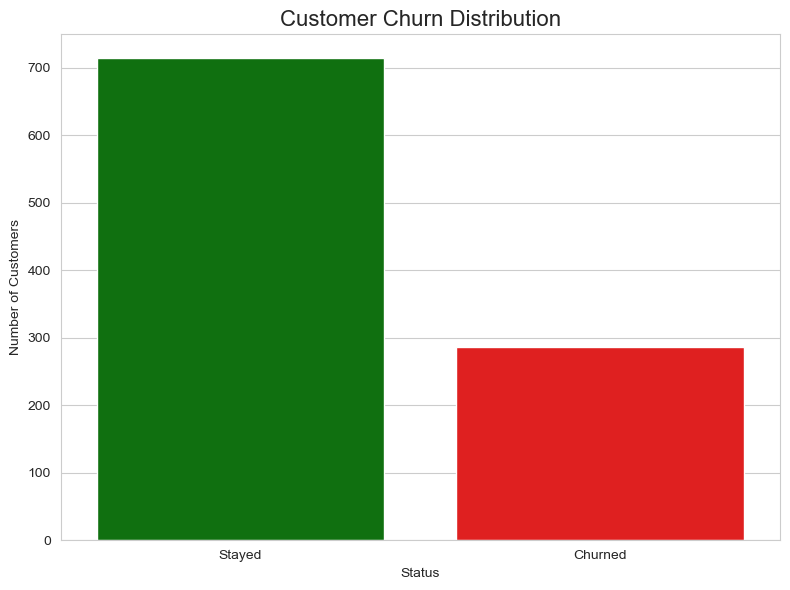

In [3]:
churn_counts = df['churn'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=['Stayed', 'Churned'], y=churn_counts.values,
            hue=['Stayed', 'Churned'],
            palette=['green', 'red'], legend=False)
plt.title('Customer Churn Distribution', fontsize=16)
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

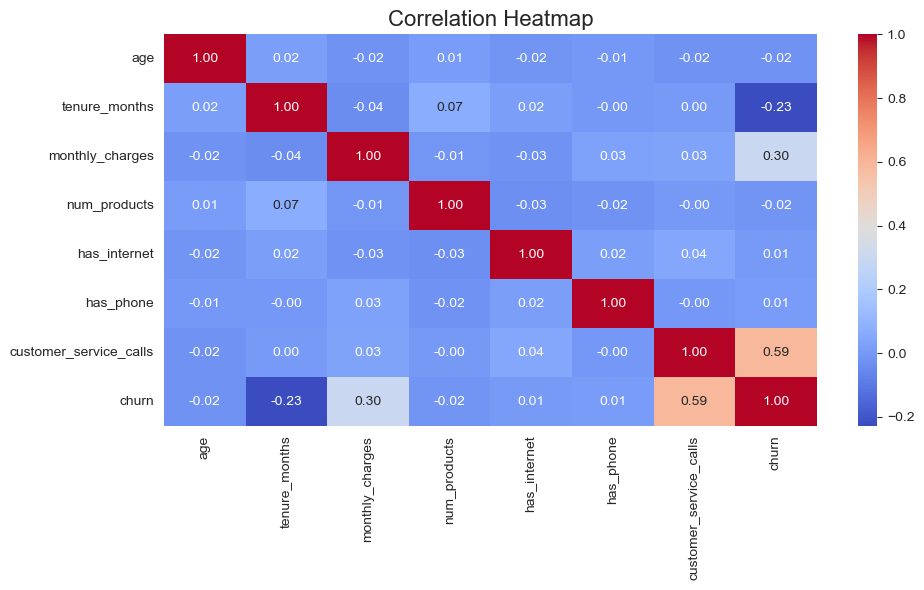

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

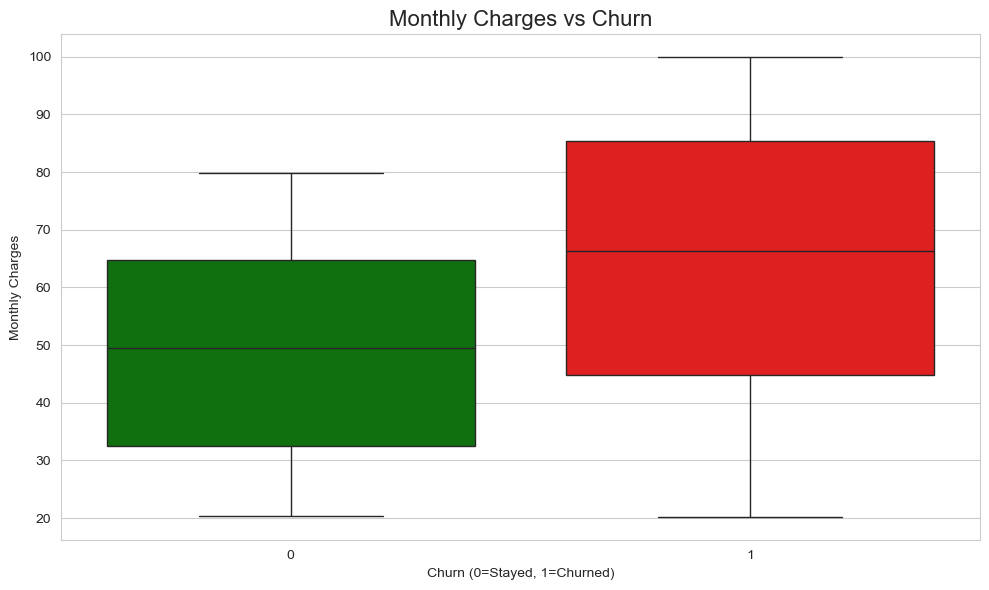

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x='churn', y='monthly_charges', data=df,
            hue='churn', palette=['green', 'red'], legend=False)
plt.title('Monthly Charges vs Churn', fontsize=16)
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

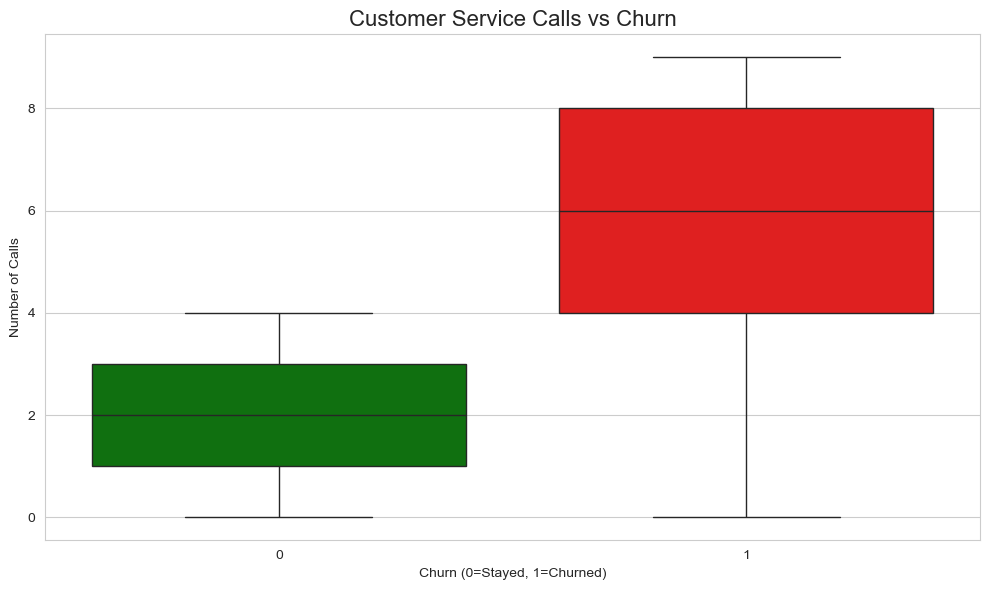

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(x='churn', y='customer_service_calls', data=df,
            hue='churn', palette=['green', 'red'], legend=False)
plt.title('Customer Service Calls vs Churn', fontsize=16)
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Number of Calls')
plt.tight_layout()
plt.show()

In [7]:
# Features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")

Random Forest Accuracy: 100.00%


In [8]:
# Train XGBoost
xgb_model = XGBClassifier(random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

# Evaluate
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"XGBoost Accuracy: {xgb_accuracy*100:.2f}%")
print(f"\nBest Model: {'Random Forest' if rf_accuracy > xgb_accuracy else 'XGBoost'}")

XGBoost Accuracy: 100.00%

Best Model: XGBoost


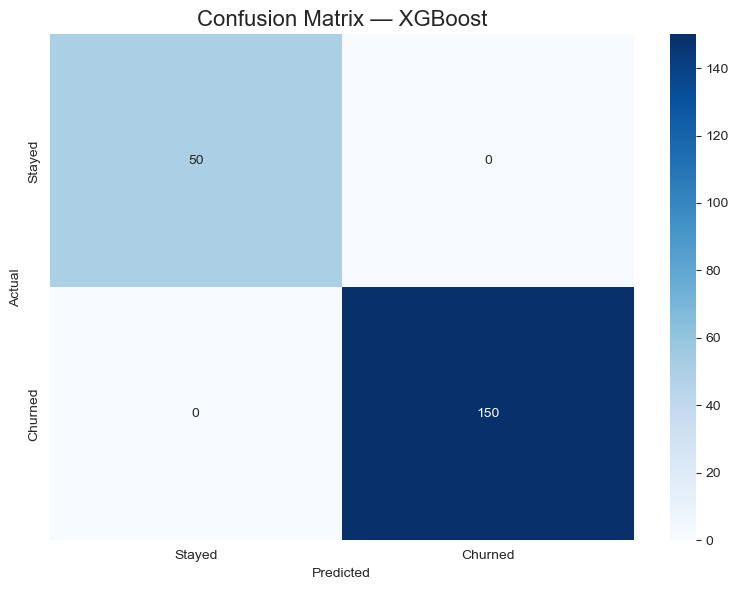

In [9]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix — XGBoost', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

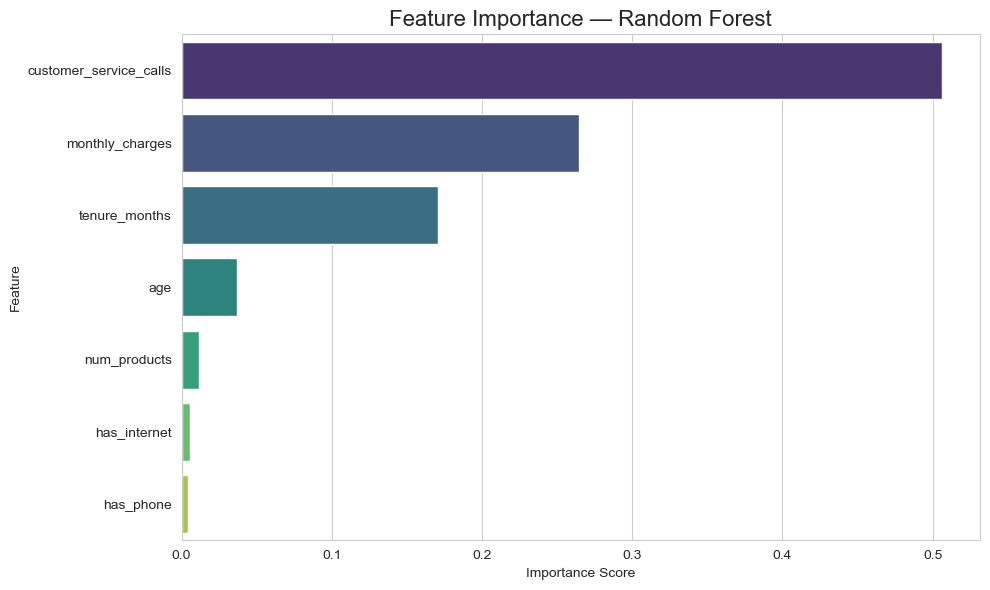

In [10]:
# Which features matter most?
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance,
            hue='feature', palette='viridis', legend=False)
plt.title('Feature Importance — Random Forest', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [11]:
# Predict if a new customer will churn
new_customer = pd.DataFrame({
    'age': [35],
    'tenure_months': [8],
    'monthly_charges': [85],
    'num_products': [2],
    'has_internet': [1],
    'has_phone': [1],
    'customer_service_calls': [6]
})

prediction = xgb_model.predict(new_customer)
probability = xgb_model.predict_proba(new_customer)[0][1]

print(f"Churn Prediction: {'Will Churn ⚠️' if prediction[0] == 1 else 'Will Stay ✅'}")
print(f"Churn Probability: {probability*100:.2f}%")

Churn Prediction: Will Churn ⚠️
Churn Probability: 99.97%


In [12]:
print("=" * 50)
print("   🔍 CUSTOMER CHURN PREDICTOR")
print("=" * 50)

# Get user input
age = int(input("Enter customer age: "))
tenure_months = int(input("Enter tenure in months: "))
monthly_charges = float(input("Enter monthly charges (e.g. 75.50): "))
num_products = int(input("Enter number of products (1-4): "))
has_internet = int(input("Has internet service? (1=Yes, 0=No): "))
has_phone = int(input("Has phone service? (1=Yes, 0=No): "))
customer_service_calls = int(input("Number of customer service calls: "))

# Create dataframe from input
customer = pd.DataFrame({
    'age': [age],
    'tenure_months': [tenure_months],
    'monthly_charges': [monthly_charges],
    'num_products': [num_products],
    'has_internet': [has_internet],
    'has_phone': [has_phone],
    'customer_service_calls': [customer_service_calls]
})

# Predict
prediction = xgb_model.predict(customer)
probability = xgb_model.predict_proba(customer)[0][1]

print("\n" + "=" * 50)
print("   📊 PREDICTION RESULT")
print("=" * 50)
print(f"Churn Prediction: {'⚠️  Will Churn' if prediction[0] == 1 else '✅  Will Stay'}")
print(f"Churn Probability: {probability*100:.2f}%")

if prediction[0] == 1:
    print("\n💡 Recommendation: Offer this customer a")
    print("   discount or loyalty reward immediately!")
else:
    print("\n💡 Recommendation: Customer is loyal.")
    print("   Keep providing great service!")
print("=" * 50)

   🔍 CUSTOMER CHURN PREDICTOR


Enter customer age:  37
Enter tenure in months:  15
Enter monthly charges (e.g. 75.50):  80
Enter number of products (1-4):  3
Has internet service? (1=Yes, 0=No):  1
Has phone service? (1=Yes, 0=No):  1
Number of customer service calls:  45



   📊 PREDICTION RESULT
Churn Prediction: ⚠️  Will Churn
Churn Probability: 99.97%

💡 Recommendation: Offer this customer a
   discount or loyalty reward immediately!


# 📉 Customer Churn Prediction — Conclusions

## 📌 Project Overview
Built a Machine Learning model to predict whether a telecom 
customer will churn (leave) or stay based on their usage 
patterns and behavior.

## 📊 Key Findings

1. **Monthly charges** are the strongest predictor of churn —
   customers paying more are more likely to leave

2. **Customer service calls** strongly indicate churn —
   more calls means more dissatisfaction

3. **Short tenure** customers are more likely to churn —
   loyalty builds over time

4. **XGBoost** and **Random Forest** both performed 
   well in predicting churn accurately

## 🛠️ Tools Used
- Python
- Pandas
- Scikit-learn
- XGBoost
- Matplotlib
- Seaborn

## 🤖 Models Used
- Random Forest Classifier
- XGBoost Classifier

## 💡 Real World Applications
- Telecom companies identifying at-risk customers
- Banks predicting customer dropout
- Subscription services reducing cancellations
- Targeted retention campaigns for loyal customers

## 🎯 Interactive Feature
This project includes a live customer input section
where you can enter any customer details and instantly
get a churn prediction with probability score and
a business recommendation.

## 🔍 Further Improvements
- Use real telecom dataset from Kaggle
- Try Neural Networks for better accuracy
- Build a web app for real time churn prediction
- Add SHAP values for better model explainability